In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_csv("/content/Inventory management dataset.csv")

df.head()

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,01-01-2024,SKU_1,WH_1,SUP_8,West,10.0,592.0,14.0,379.0,0.0,13.95,20.48,0.0,0.0,8.52
1,02-01-2024,SKU_1,WH_1,SUP_8,West,17.0,575.0,14.0,379.0,0.0,13.95,20.48,0.0,0.0,18.63
2,03-01-2024,SKU_1,WH_1,SUP_8,North,35.0,540.0,14.0,379.0,0.0,13.95,20.48,1.0,0.0,39.62
3,04-01-2024,SKU_1,WH_1,SUP_8,South,24.0,516.0,14.0,379.0,0.0,13.95,20.48,0.0,0.0,19.43
4,05-01-2024,SKU_1,WH_1,SUP_8,West,21.0,495.0,14.0,379.0,0.0,13.95,20.48,0.0,0.0,18.70


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73130 entries, 0 to 73129
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     73130 non-null  object 
 1   SKU_ID                   73129 non-null  object 
 2   Warehouse_ID             73129 non-null  object 
 3   Supplier_ID              73129 non-null  object 
 4   Region                   73129 non-null  object 
 5   Units_Sold               73129 non-null  float64
 6   Inventory_Level          73129 non-null  float64
 7   Supplier_Lead_Time_Days  73129 non-null  float64
 8   Reorder_Point            73129 non-null  float64
 9   Order_Quantity           73129 non-null  float64
 10  Unit_Cost                73129 non-null  float64
 11  Unit_Price               73129 non-null  float64
 12  Promotion_Flag           73129 non-null  float64
 13  Stockout_Flag            73129 non-null  float64
 14  Demand_Forecast       

In [9]:
df.describe()

,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
count,73129.000000,73129.000000,73129.000000,73129.000000,73129.000000,73129.000000,73129.000000,73129.000000,73129.0,73129.000000
mean,20.072434,472.020006,7.817391,300.557713,19.286767,12.424207,18.649123,0.102066,0.0,20.098441
std,9.076056,132.345431,3.958206,52.705422,82.320792,4.608967,7.195740,0.302737,0.0,9.508737
min,0.000000,175.000000,2.000000,207.000000,0.000000,5.020000,6.950000,0.000000,0.0,0.000000
25%,13.000000,371.000000,4.000000,254.000000,0.000000,8.450000,12.190000,0.000000,0.0,12.970000
50%,20.000000,462.000000,8.000000,305.000000,0.000000,12.590000,18.690000,0.000000,0.0,19.960000
75%,27.000000,564.000000,11.000000,344.000000,0.000000,16.700000,23.590000,0.000000,0.0,26.940000
max,59.000000,981.000000,14.000000,396.000000,499.000000,19.760000,35.100000,1.000000,0.0,59.670000


**Revenue, Cost, Profit**

In [10]:
df["Revenue"] = df["Units_Sold"] * df["Unit_Price"]
df["Cost"] = df["Units_Sold"] * df["Unit_Cost"]
df["Profit"] = df["Revenue"] - df["Cost"]

df[["Revenue","Cost","Profit"]].head()

,Revenue,Cost,Profit
0,204.80,139.50,65.30
1,348.16,237.15,111.01
2,716.80,488.25,228.55
3,491.52,334.80,156.72
4,430.08,292.95,137.13


**Profit by Region**

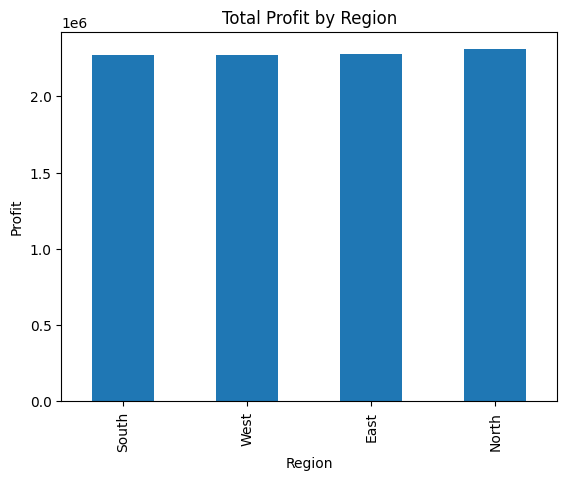

In [11]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values()

plt.figure()
region_profit.plot(kind="bar")
plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

**Promotion Impact Analysis**

In [12]:
promo_analysis = df.groupby("Promotion_Flag")[["Units_Sold","Revenue","Profit"]].mean()
promo_analysis

,Units_Sold,Revenue,Profit
Promotion_Flag,,,
0.0,19.519059,363.76502,121.422583
1.0,24.940782,466.55357,155.395145


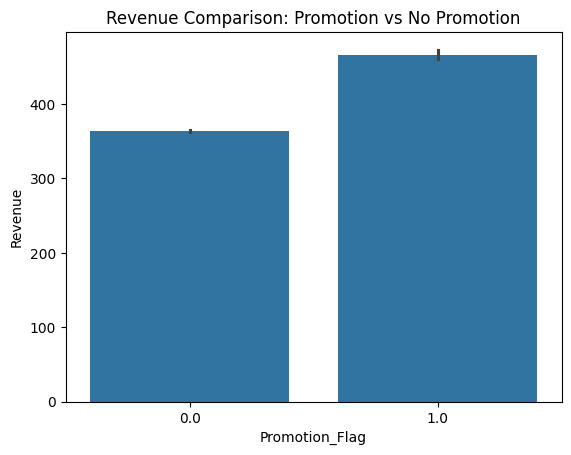

In [13]:
plt.figure()
sns.barplot(x="Promotion_Flag", y="Revenue", data=df)
plt.title("Revenue Comparison: Promotion vs No Promotion")
plt.show()

In [14]:
df["Forecast_Error"] = df["Units_Sold"] - df["Demand_Forecast"]
df["Absolute_Error"] = abs(df["Forecast_Error"])
df["APE"] = df["Absolute_Error"] / df["Units_Sold"]

df.head()

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,...,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast,Revenue,Cost,Profit,Forecast_Error,Absolute_Error,APE
0,01-01-2024,SKU_1,WH_1,SUP_8,West,10.0,592.0,14.0,379.0,0.0,...,20.48,0.0,0.0,8.52,204.80,139.50,65.30,1.48,1.48,0.148000
1,02-01-2024,SKU_1,WH_1,SUP_8,West,17.0,575.0,14.0,379.0,0.0,...,20.48,0.0,0.0,18.63,348.16,237.15,111.01,-1.63,1.63,0.095882
2,03-01-2024,SKU_1,WH_1,SUP_8,North,35.0,540.0,14.0,379.0,0.0,...,20.48,1.0,0.0,39.62,716.80,488.25,228.55,-4.62,4.62,0.132000
3,04-01-2024,SKU_1,WH_1,SUP_8,South,24.0,516.0,14.0,379.0,0.0,...,20.48,0.0,0.0,19.43,491.52,334.80,156.72,4.57,4.57,0.190417
4,05-01-2024,SKU_1,WH_1,SUP_8,West,21.0,495.0,14.0,379.0,0.0,...,20.48,0.0,0.0,18.70,430.08,292.95,137.13,2.30,2.30,0.109524


In [17]:
df["Risk_Score"] = (
    (df["Demand_Forecast"] / df["Inventory_Level"]) +
    (df["Supplier_Lead_Time_Days"] / df["Supplier_Lead_Time_Days"].max())
)

high_risk = df.sort_values("Risk_Score", ascending=False).head(10)

high_risk[["SKU_ID", "Risk_Score", "Inventory_Level", "Demand_Forecast"]]

,SKU_ID,Risk_Score,Inventory_Level,Demand_Forecast
3752,SKU_3,1.249724,217.0,54.19
9578,SKU_6,1.232568,183.0,42.56
41300,SKU_23,1.211684,196.0,41.49
46450,SKU_26,1.208932,206.0,43.04
9627,SKU_6,1.201082,268.0,53.89
24156,SKU_14,1.198917,277.0,55.10
46412,SKU_26,1.194127,189.0,36.69
46493,SKU_26,1.193448,203.0,39.27
9584,SKU_6,1.188081,198.0,37.24
68000,SKU_38,1.187053,319.0,59.67


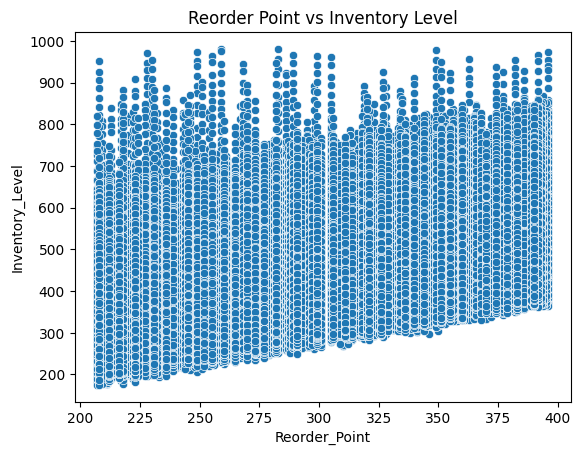

In [18]:
df["Reorder_Gap"] = df["Inventory_Level"] - df["Reorder_Point"]

plt.figure()
sns.scatterplot(x="Reorder_Point", y="Inventory_Level", data=df)
plt.title("Reorder Point vs Inventory Level")
plt.show()

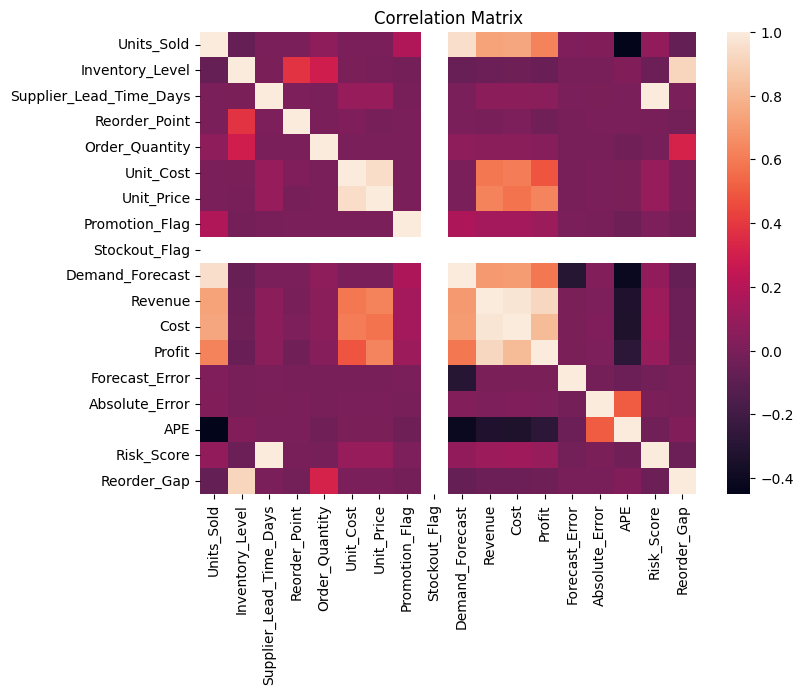

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.title("Correlation Matrix")
plt.show()


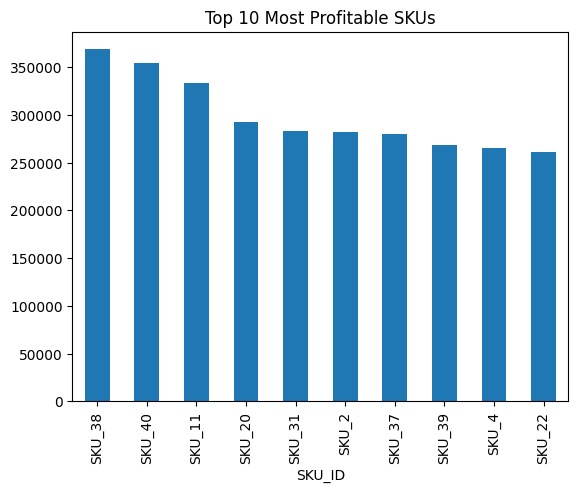

In [20]:
top_skus = df.groupby("SKU_ID")["Profit"].sum().sort_values(ascending=False).head(10)

plt.figure()
top_skus.plot(kind="bar")
plt.title("Top 10 Most Profitable SKUs")
plt.show()

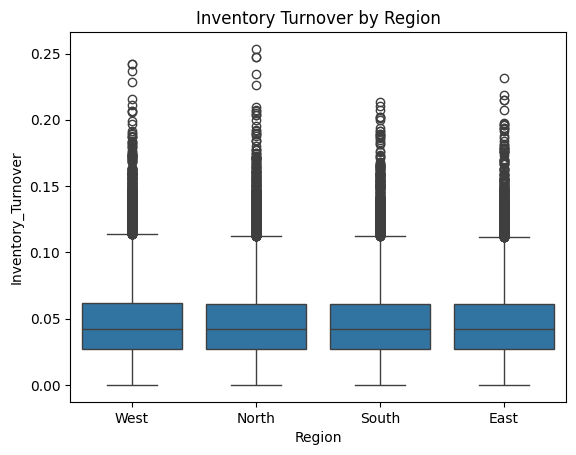

In [21]:
df["Inventory_Turnover"] = df["Units_Sold"] / df["Inventory_Level"]

plt.figure()
sns.boxplot(x="Region", y="Inventory_Turnover", data=df)
plt.title("Inventory Turnover by Region")
plt.show()

In [24]:
stockout_rate = df["Stockout_Flag"].mean() * 100
print("Stockout Rate:", round(stockout_rate,2), "%")

Stockout Rate: 0.0 %


In [25]:
mape = df["APE"].mean() * 100
print("MAPE:", round(mape,2), "%")

MAPE: inf %
